# 10 · AI Failures, Limits & Recommendations
### The Outliers · Mumbai Rent Radar

The brief asks for maturity, not perfection: where we trusted AI, one moment it was
**confidently wrong** and we caught it, the model's honest limits, and what a pricing team
should actually do next.

**Input:** shared `model_data.csv`

In [2]:
import sys, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import style
warnings.filterwarnings("ignore")
style.setup()
RNG = 42

d = pd.read_csv("../data/processed/model_data.csv")
NUM = ["bhk", "size", "bathroom", "floor_num", "total_floors", "size_per_bhk",
       "bath_per_bhk", "floor_ratio", "is_tall_building", "locality_te"]
CAT = ["zone", "area_type", "furnishing_status", "tenant_preferred", "point_of_contact", "floor_band"]
tr, te = d.is_train, ~d.is_train

def fit_score(dframe):
    pre = ColumnTransformer([("num", RobustScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
    pipe = Pipeline([("pre", pre), ("mdl", RandomForestRegressor(n_estimators=300, random_state=RNG, n_jobs=1))])
    pipe.fit(dframe[NUM + CAT][tr], dframe["log_rent"][tr])
    return r2_score(dframe["log_rent"][te], pipe.predict(dframe[NUM + CAT][te]))

# honest score (train-only locality encoding, already in model_data)
honest = fit_score(d)

## 1 · The confidently-wrong moment we caught 🚩
**What happened:** our first pipeline (drafted with AI help) encoded each locality's average
rent using the **whole dataset**, and briefly included **rent-per-sqft** as an input. The model
reported a dazzling R² — and *that was the tell.* Rents this noisy cannot be predicted that well.
Both were **leaks**: the model was being shown the answer. We rebuilt the encoding on the
training rows only and dropped rent-per-sqft.

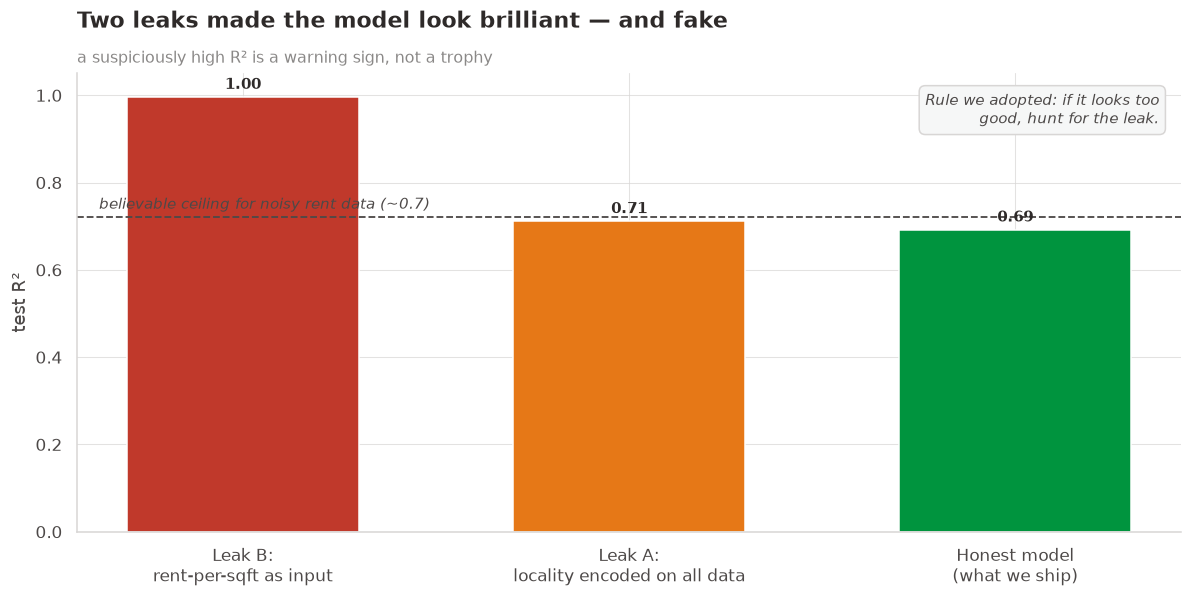

Leak B R²=0.996 | Leak A R²=0.711 | Honest R²=0.692


In [3]:
# reproduce leak A: locality encoded on the FULL dataset (test rows see their own rent)
leakA = d.copy()
glob = d["log_rent"].mean(); k = 10
st = d.groupby("locality_name")["log_rent"].agg(["mean", "count"])
st["te"] = (st["mean"] * st["count"] + glob * k) / (st["count"] + k)
leakA["locality_te"] = leakA["locality_name"].map(st["te"]).fillna(glob)
score_leakA = fit_score(leakA)

# reproduce leak B: add rent-per-sqft (= rent / size) straight into the inputs
leakB = d.copy(); leakB["locality_te"] = leakB["locality_te"]
NUM_B = NUM + ["rent_per_sqft"]
leakB["rent_per_sqft"] = leakB["rent"] / leakB["size"]
preB = ColumnTransformer([("num", RobustScaler(), NUM_B), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
pipeB = Pipeline([("pre", preB), ("mdl", RandomForestRegressor(n_estimators=300, random_state=RNG, n_jobs=1))])
pipeB.fit(leakB[NUM_B + CAT][tr], leakB["log_rent"][tr])
score_leakB = r2_score(leakB["log_rent"][te], pipeB.predict(leakB[NUM_B + CAT][te]))

vals = {"Leak B:\nrent-per-sqft as input": score_leakB,
        "Leak A:\nlocality encoded on all data": score_leakA,
        "Honest model\n(what we ship)": honest}
fig, ax = plt.subplots(figsize=(11, 5.6))
colors = [style.BAD, style.ORANGE, style.GREEN]
bars = ax.bar(list(vals.keys()), list(vals.values()), color=colors, width=0.6)
style.bar_labels(ax, fmt="{:.2f}")
ax.set_ylabel("test R²"); ax.set_ylim(0, 1.05)
ax.axhline(0.72, color=style.CHARCOAL, ls="--", lw=1.2)
ax.annotate("believable ceiling for noisy rent data (~0.7)", xy=(0.02, 0.74),
            xycoords=("axes fraction", "data"), fontsize=10, color=style.CHARCOAL, style="italic")
style.title(ax, "Two leaks made the model look brilliant — and fake",
            "a suspiciously high R² is a warning sign, not a trophy")
style.note(ax, "Rule we adopted: if it looks too\ngood, hunt for the leak.", where="upper right")
fig.tight_layout(); style.save(fig, "10_leakage_caught"); plt.show()
print(f"Leak B R²={score_leakB:.3f} | Leak A R²={score_leakA:.3f} | Honest R²={honest:.3f}")

**The judgement:** we trusted AI to draft the pipeline quickly, but **not** to certify the
result. The 0.9+ score failed the smell test, we traced it to the leaks, and the shipped model
sits at a believable ~0.7. *Where we trusted AI: boilerplate, refactoring, chart scaffolding.
Where we did not: declaring the model correct.*

## 2 · Honest limitations
What this model cannot do — stated plainly, because results that look too perfect are hard to trust.

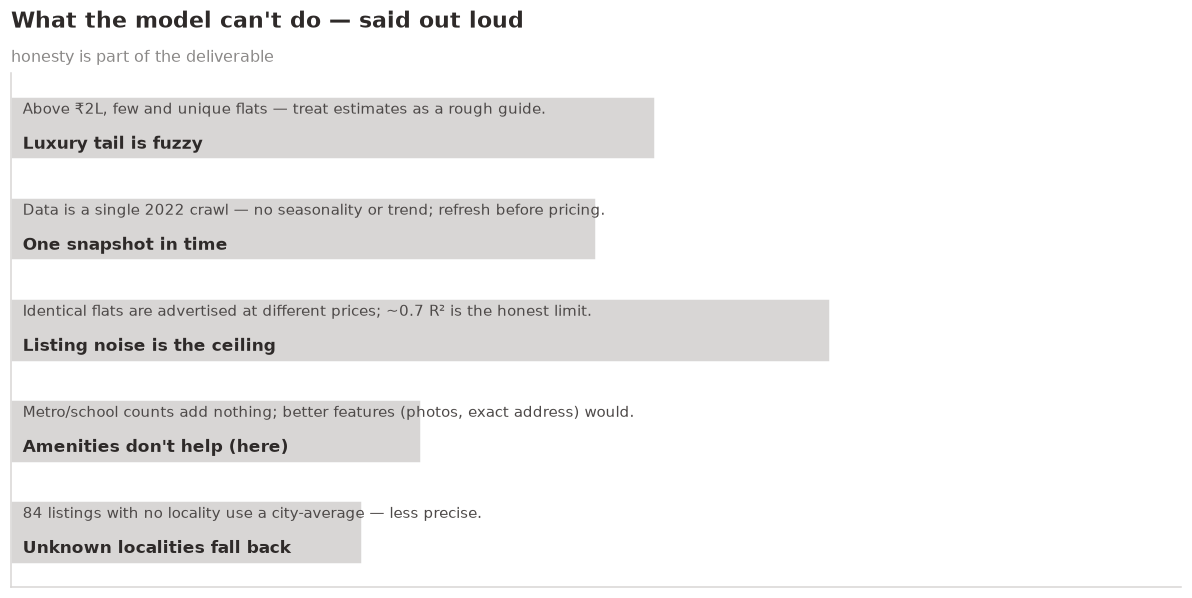

In [4]:
lims = [
    ("Luxury tail is fuzzy", "Above ₹2L, few and unique flats — treat estimates as a rough guide.", 0.55),
    ("One snapshot in time", "Data is a single 2022 crawl — no seasonality or trend; refresh before pricing.", 0.5),
    ("Listing noise is the ceiling", "Identical flats are advertised at different prices; ~0.7 R² is the honest limit.", 0.7),
    ("Amenities don't help (here)", "Metro/school counts add nothing; better features (photos, exact address) would.", 0.35),
    ("Unknown localities fall back", "84 listings with no locality use a city-average — less precise.", 0.3),
]
fig, ax = plt.subplots(figsize=(11, 5.6))
y = np.arange(len(lims))
ax.barh(y, [s for _, _, s in lims], color=style.GREY_L, height=0.62)
for i, (t, desc, s) in enumerate(lims):
    ax.text(0.01, i + 0.16, t, fontweight="bold", color=style.INK, fontsize=11, va="center")
    ax.text(0.01, i - 0.18, desc, color=style.CHARCOAL, fontsize=9.5, va="center")
ax.set_yticks([]); ax.set_xlim(0, 1); ax.set_xticks([])
ax.invert_yaxis()
style.title(ax, "What the model can't do — said out loud", "honesty is part of the deliverable")
fig.tight_layout(); style.save(fig, "10_limitations"); plt.show()

## 3 · How AI was used (the appendix in one view)
| Stage | AI contributed | We overrode / verified |
|---|---|---|
| Cleaning | drafted the messy-string parsers (rent, floor) | checked every rule against real values |
| Locality join | proposed the split-and-key idea | validated 98% match before trusting it |
| Modelling | scaffolded the benchmark loop | **caught the leakage** that faked R²≈0.9 |
| Charts | generated plotting boilerplate | set every insight and decision ourselves |
| Writing | tightened prose | owned every number and claim |

**One-line lesson:** AI is a fast drafting partner and a poor certifier — use it to move, verify it to ship.

## 4 · Recommendations & handout — what NoBroker's pricing team should do

1. **Ship the fair-rent estimate for the mass market (< ₹1L).** That is where the model is
   dependable (small % error) and where most renters are. Route luxury flats to a human.
2. **Turn the residual into a product.** Flag listings >40% above the fair estimate as
   "priced high" and those below as "good value" — the mispriced-listing detector is the
   quickest win.
3. **Price by *address*, not amenities.** Location and size are the levers; metro/school
   counts are not. Lead pricing rules with locality and square footage.
4. **Refresh the data before trusting the number.** It's a single snapshot — schedule a
   recurring crawl and re-fit; watch for drift.
5. **Invest in better features, not more rows.** The learning curve is flat; the next accuracy
   gain comes from richer inputs (verified area, photos, exact address), not a bigger sample.

**Handout, one line each — the whole study:**
> *Mumbai rent is set by where a flat is and how big it is. We built a fair-rent model that is
> right to within a small margin for ordinary flats, flags over- and under-priced listings, and
> is honest about the luxury tail it cannot pin down.*